# Fraud Detection - Modeling & Evaluation

## Objectives

In this notebook I train and evaluate two classification models on the processed data from `02_feature_engineering.ipynb`: Logistic Regression as the baseline model and Random Forest to capture any non-linear relationships. I use `RandomizedSearchCV` (does cross-valudation internally, ensuring evaluation reliability) on stratified subsample for hyperparameter tuning. 

Model performance is evaluated using accuracy, recall, precision, F1-score, AUC-ROC, and PR-AUC — with an emphasis on recall since false negatives (missed fraud cases) are more costly than false positives (misclassifying legit cases as fraud). 

Lastly, I apply segmentation analysis on transaction type to verify the model's reliability across different transaction types — fraud cases were concentrated in only two of the different transaction types, so focusing on which transactions to focus on can save businesses time and resources. 

## Output

- Trained Logistic Regression and Random Forest models
- Recommended model with performance metrics
- Justification for model choice and business relevance
- Visualizations for README

## 3.1 Setup & Imports
Importing most of the same libraries and absolute paths like numpy, pandas, and X and y train/test paths. Addition of sklearn model libraries for Logistic Regression, Random Forest, `RandomizedSearchCV`, evaluation metrics, as well as graphing libraries for README visualization.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split

# evaluation
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import make_scorer, fbeta_score


RANDOM_STATE = 42
X_TRAIN_PATH = '../data/processed/X_train.parquet'
X_TEST_PATH = '../data/processed/X_test.parquet'
Y_TRAIN_PATH = '../data/processed/y_train.parquet'
Y_TEST_PATH = '../data/processed/y_test.parquet'

## 3.2 Load Processed Data

Loading the four processed datasets saved from `02_feature_engineering.ipynb` using the path constants defined in section `3.1`. `.squeeze()` is applied to `y_train` and `y_test` to convert them from single-column DataFrames to 1D Series, which is the format sklearn models expect for target variables.

(Note: an earlier version of this notebook surfaced a `NaN` issue in `X_train` traced back to `oldbalanceOrg == 0`; this was resolved upstream in `02_feature_engineering.ipynb`, section `2.4.5`.)

In [3]:
X_train = pd.read_parquet(X_TRAIN_PATH)
X_test = pd.read_parquet(X_TEST_PATH)
y_train = pd.read_parquet(Y_TRAIN_PATH).squeeze()
y_test = pd.read_parquet(Y_TEST_PATH).squeeze()

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5069097, 13), (1293523, 13), (5069097,), (1293523,))

`.shape` confirms the four datasets were loaded correctly — `X_train` ((5069097, 13)), `X_test` (1293523, 13), `y_train` (5069097,), `y_test` (1293523,) — matching the expected shapes from `02_feature_engineering.ipynb` and confirming 1D target series after `.squeeze()`.

## 3.3 Handle Class Imbalance

I use class weighting to handle the class imbalance since it doesn't require data modification, and undersampling or oversampling/SMOTE would either discard too much real data or be computationally impractical given the ~5M training set rows. This will be implemented by passing `class_weight='balanced'` into the classification models. 

## 3.4 Baseline Model: Logistic Regression (LR)

I implement Logistic Regression as the baseline model using sklearn's `LogisticRegression`. This is an appropriate baseline because it models the linear relationship between features and the log-odds of the target (`isFraud`), is highly interpretable, and serves as a strong reference point before introducing more complex models like Random Forest. The model is fit on `X_train` and `y_train`, then used to generate both class predictions and probability scores for PR-AUC/AUC-ROC evaluation. `random_state=RANDOM_STATE` ensures reproducibility. 

In [ ]:
# create logistic regression
lr = LogisticRegression(random_state= RANDOM_STATE, class_weight='balanced')
# fit
lr.fit(X_train, y_train)
# predict
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:,1] # [:,1] selects probability of class 1 (isFraud=1) for AUC-ROC/PR-AUC

To evaluate performance I report accuracy, precision, recall, F1-score, AUC-ROC, and PR-AUC — with recall on class 1 (`isFraud=1`) as the most important metric since missing a fraud case is more costly than a false alarm. I also produce a confusion matrix heatmap to visualize TP, TN, FP, and FN counts directly.

In [16]:
# evaluation metrics
print(classification_report(y_test, y_pred_lr))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_lr))
print('PR-AUC score:', average_precision_score(y_test, y_pred_proba_lr))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1289265
           1       0.07      0.90      0.12      4258

    accuracy                           0.96   1293523
   macro avg       0.53      0.93      0.55   1293523
weighted avg       1.00      0.96      0.98   1293523

AUC-ROC score: 0.9628430838076574
PR-AUC score: 0.6236992314838238


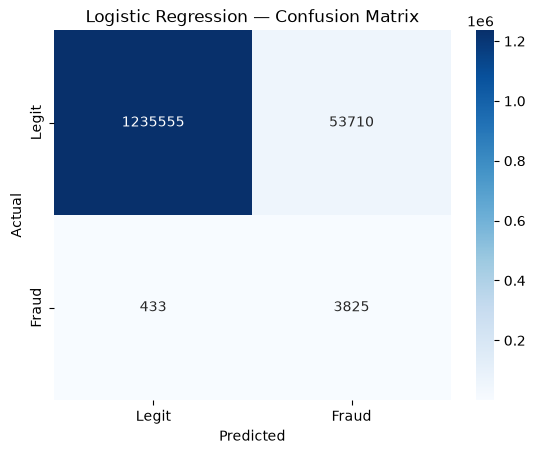

In [17]:
# heatmap confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot = True, fmt = 'd', cmap= 'Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/Logistic_Regression_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

`Precision` for fraud cases is extremely low (0.07), which is expected given the class imbalance, by balancing class weights it shifted the decision threshold to catch more fraud increasing the number of false positive. `Recall`, the most important metric, is high for fraud cases (0.90) because `class_weight='balanced'` penalizes missed fraud more heavily. `Precision` and `Recall` have a inverse relationship, increase in `recall` reduces `precision` and vice versa. 

`f1-score` for fraud cases is 0.12, which is expectedly low since `f1-score` is the harmonic mean of `recall` and `precision` — `precisions`'s low 0.07 drags down the overall harmonic mean. 

`accuracy` of 0.96, while high, is misleading since the class was heavily imbalanced. However, the naive baseline for `accuracy`(~99.87%, found in EDA) being higher than the model's `accuracy`(96%) confirms that the model correctly traded `accuracy` for higher `recall`, which is more important and highlights how useless `accuracy` is as a metric. 

`AUC-ROC` has a high score at ~0.96, but this metric is not reliable since the number of FP (53710) is small relative to the size of the negative class. Therefore, I also evaluated the model using `PR-AUC` which is a more reliable because its `precision` and `recall`, and by not including TN in either axis gives a more accurate evaluation since the severe imbalance of TN won't affect the metric. `PR-AUC` (~0.62) is expected since precision for fraud was extremely low.  

All the metrics for legit cases are expectedly high due to the imbalance. 

(Note: During random forest modeling, I found that `amount_to_oldbalanceOrg_ratio` and `balance_drained_ratio` were causing data leakage, and retrained the RF model on the dataset with those two features dropped. Section 3.5.5 has a retrained LR model without `amount_to_oldbalanceOrg_ratio` and `balance_drained_ratio`.)

## 3.5 Random Forest Model (RF)

In addition to the baseline LR model, I implement Random Forest to capture any non-linear relationships LR may have missed — such as the relationship between `balance_drained_ratio`/`type`, a `TRANSFER` transaction where `balance_drained_ratio` is close to 1 suggests a person's whole account was transferred to another (a classic fraud pattern). I initialize with `n_estimators=100` as a standard starting point before tuning, set `random_state=RANDOM_STATE` for reproducibility, and `class_weight='balanced'` to handle class imbalance consistently with the baseline model. Additionally, RF gives native feature importances for later feature importances. 

In [16]:
# create RF
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1) # n_jobs=-1 just to speed up training
# fit
rf.fit(X_train, y_train)
# predict
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:,1] # [:,1] selects probability of class 1 (isFraud=1) for AUC-ROC/PR-AUC

Evaluation follows the same approach as LR — accuracy, precision, recall, F1-score, AUC-ROC, PR-AUC, and a confusion matrix heatmap — with recall on class 1 (`IsFraud=1`) being the most important metric. 

In [6]:
# evaluation metrics
print(classification_report(y_test, y_pred_rf))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_rf))
print('PR-AUC score:', average_precision_score(y_test, y_pred_proba_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289265
           1       1.00      1.00      1.00      4258

    accuracy                           1.00   1293523
   macro avg       1.00      1.00      1.00   1293523
weighted avg       1.00      1.00      1.00   1293523

AUC-ROC score: 0.9999999887061025
PR-AUC score: 0.9999961998038471


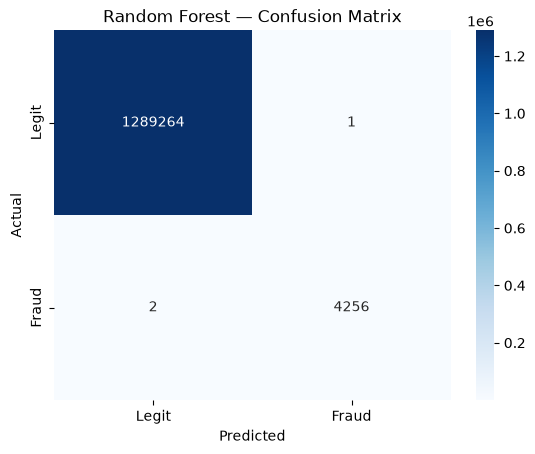

In [7]:
# heatmap confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot = True, fmt = 'd', cmap= 'Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/Random_Forest_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

All metric values being ~1 is extremely suspicious and is likely due to some data leakage. I suspect this leakage came from the engineered features, `amount_to_oldbalanceOrg_ratio` and `balance_drained_ratio`(conceptually similar), but specifically `amount_to_oldbalanceOrg_ratio`. 

Given the dataset was created through simulated transactions, its likely that `amount_to_oldbalanceOrg_ratio` is too close to the label-generating mechanism of the simulation. 

To confirm this I will re-train another RF with the engineered features dropped, getting more realistic metrics will confirm if the leakage was due to these features. 

In [9]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

amount_to_oldbalanceOrg_ratio    0.396698
oldbalanceOrg                    0.171424
balance_drained_ratio            0.084864
newbalanceOrig                   0.074238
amount_log                       0.056998
amount                           0.046512
type_TRANSFER                    0.040882
oldbalanceOrg_was_zero           0.036825
type_PAYMENT                     0.032742
newbalanceDest                   0.022703
oldbalanceDest                   0.018913
type_CASH_OUT                    0.017056
type_DEBIT                       0.000145
dtype: float64


The feature importance of `amount_to_oldbalanceOrg_ratio` (~0.40) is disproportionately more important than all the other features, further supporting my suspicion that `amount_to_oldbalanceOrg_ratio` is likely the cause of this data leakage.

## 3.5.1 RF With Engineered Features Dropped

In [4]:
# create new X_train and test
X_train_no_leak = X_train.drop(columns=['amount_to_oldbalanceOrg_ratio', 'balance_drained_ratio'])
X_test_no_leak = X_test.drop(columns=['amount_to_oldbalanceOrg_ratio', 'balance_drained_ratio'])
# create rf
rf_no_leak = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1) # n_jobs=-1 just to speed up training
# fit
rf_no_leak.fit(X_train_no_leak, y_train)
# predict
y_pred_rf_no_leak = rf_no_leak.predict(X_test_no_leak)
y_pred_proba_rf_no_leak = rf_no_leak.predict_proba(X_test_no_leak)[:,1] # [:,1] selects probability of class 1 (isFraud=1) for AUC-ROC/PR-AUC

In [11]:
# evaluation metrics
print(classification_report(y_test, y_pred_rf_no_leak))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_rf_no_leak))
print('PR-AUC score:', average_precision_score(y_test, y_pred_proba_rf_no_leak))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289265
           1       0.97      0.83      0.90      4258

    accuracy                           1.00   1293523
   macro avg       0.99      0.92      0.95   1293523
weighted avg       1.00      1.00      1.00   1293523

AUC-ROC score: 0.9977997598797181
PR-AUC score: 0.9747170981203841


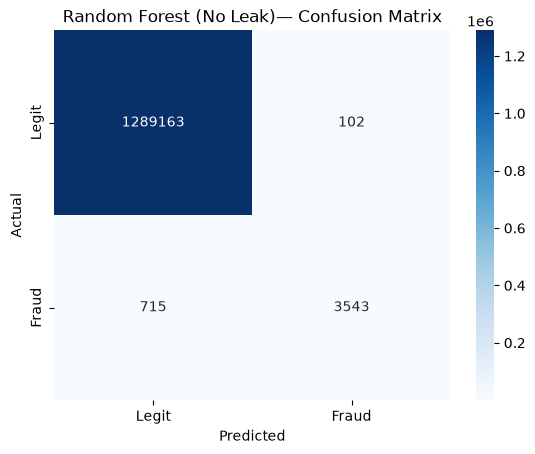

In [12]:
# heatmap confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf_no_leak), annot = True, fmt = 'd', cmap= 'Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Random Forest (No Leak)— Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/Random_Forest_No_Leak_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

The retrained `rf_no_leak` model `precision`(0.97) dropped slightly, but still remained high while `recall`(0.83) dropped significantly more after retraining. Given `recall` is the most important metric (missing a fraud case is more costly than a false alarm), it being 0.83 is not ideal. 

`f1-score`(0.90), `AUC-ROC`(~0.998), and `PR-AUC`(~0.975) all dropped from their original ~1.0, which is much more realistic. 

However, I additionally suspect that `newbalanceOrig` could independently encode the same drain-to-zero rule as the dropped `amount_to_oldbalanceOrg_ratio`, just in raw form rather than as a ratio.

In [13]:
no_leak_importances = pd.Series(rf_no_leak.feature_importances_, index=X_train_no_leak.columns).sort_values(ascending=False)
print(no_leak_importances)

oldbalanceOrg             0.283327
newbalanceOrig            0.171203
amount_log                0.109277
amount                    0.093573
type_TRANSFER             0.075870
oldbalanceOrg_was_zero    0.063665
type_PAYMENT              0.060431
oldbalanceDest            0.050376
type_CASH_OUT             0.046923
newbalanceDest            0.044943
type_DEBIT                0.000413
dtype: float64


`oldbalanceOrg`(~0.28) and `newbalanceOrig`(~0.17) are the two highest-importance features by a wide margin, further supporting my suspicion and prompting the follow-up check in `3.5.2`.  

## 3.5.2 RF Retrain With `newbalanceOrig` Dropped (V2)

In `01_eda.ipynb` section `1.3.5`, I investigated further into `newbalanceOrig` and found evidence to support dropping it. 

In [12]:
# create new X_train and test
X_train_no_leak_v2 = X_train_no_leak.drop(columns=['newbalanceOrig'])
X_test_no_leak_v2 = X_test_no_leak.drop(columns=['newbalanceOrig'])
# create rf
rf_no_leak_v2 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1) # n_jobs=-1 just to speed up training
# fit
rf_no_leak_v2.fit(X_train_no_leak_v2, y_train)
# predict
y_pred_rf_no_leak_v2 = rf_no_leak_v2.predict(X_test_no_leak_v2)
y_pred_proba_rf_no_leak_v2 = rf_no_leak_v2.predict_proba(X_test_no_leak_v2)[:,1] # [:,1] selects probability of class 1 (isFraud=1) for AUC-ROC/PR-AUC

In [24]:
# evaluation metrics
print(classification_report(y_test, y_pred_rf_no_leak_v2))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_rf_no_leak_v2))
print('PR-AUC score:', average_precision_score(y_test, y_pred_proba_rf_no_leak_v2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289265
           1       0.98      0.77      0.86      4258

    accuracy                           1.00   1293523
   macro avg       0.99      0.89      0.93   1293523
weighted avg       1.00      1.00      1.00   1293523

AUC-ROC score: 0.9822313751913844
PR-AUC score: 0.9133849804186853


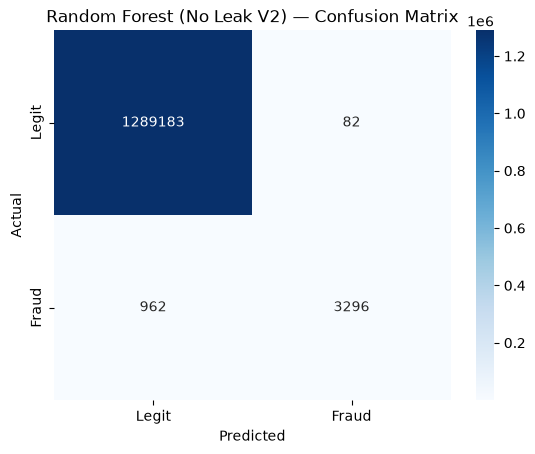

In [25]:
# heatmap confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf_no_leak_v2), annot = True, fmt = 'd', cmap= 'Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Random Forest (No Leak V2) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/Random_Forest_No_Leak_V2_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

Dropping `newbalanceOrig` caused a further drop in `recall` (0.83 -> 0.77) and `PR-AUC` (0.975 -> 0.913), a larger decline than the first retrain. This confirms `newbalanceOrig` was carrying a leaked signal beyond what the engineered ratio alone captured.

Given `recall` is the most important metric (missing fraud is more costly than a false alarm), 0.77 is a real limitation. High `precision` (0.98) suggests the model is more conservative, flagging fewer transactions but being more confident when it does. Further work is needed to recover `recall`. 

## 3.5.3 LR Without Leakage

Below is the LR model trained on the final feature set (the same features from 3.5.2: engineered ratio features and `newbalanceOrig` dropped), using `class_weight='balanced'` as in prior runs. 

In [13]:
# drop features
X_train_no_leak_v2 = X_train_no_leak.drop(columns=['newbalanceOrig'])
X_test_no_leak_v2 = X_test_no_leak.drop(columns=['newbalanceOrig'])
# create logistic regression
lr_v2 = LogisticRegression(max_iter=1000, random_state= RANDOM_STATE, class_weight='balanced') # increase iter to improve convergence
# fit
lr_v2.fit(X_train_no_leak_v2, y_train)
# predict
y_pred_lr_v2 = lr_v2.predict(X_test_no_leak_v2)
y_pred_proba_lr_v2 = lr_v2.predict_proba(X_test_no_leak_v2)[:,1] # [:,1] selects probability of class 1 (isFraud=1) for AUC-ROC/PR-AUC

In [28]:
# evaluation metrics
print(classification_report(y_test, y_pred_lr_v2))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_lr_v2))
print('PR-AUC score:', average_precision_score(y_test, y_pred_proba_lr_v2))

              precision    recall  f1-score   support

           0       1.00      0.78      0.87   1289265
           1       0.01      0.98      0.03      4258

    accuracy                           0.78   1293523
   macro avg       0.51      0.88      0.45   1293523
weighted avg       1.00      0.78      0.87   1293523

AUC-ROC score: 0.9554071046815704
PR-AUC score: 0.17909971147945047


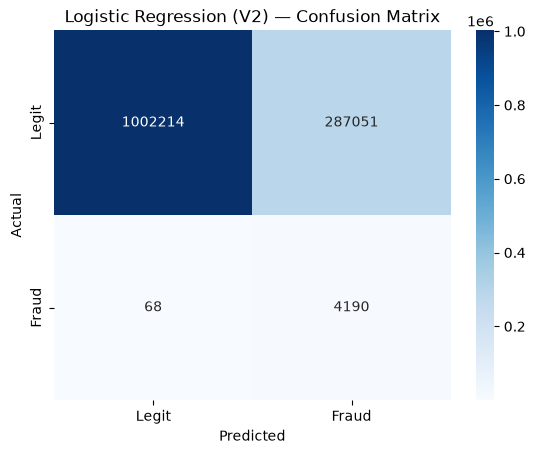

In [29]:
# heatmap confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr_v2), annot = True, fmt = 'd', cmap= 'Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Logistic Regression (V2) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/Logistic_Regression_V2_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

These results are drastically different from RF. `Precision` collapsed to 0.01 while `recall` stayed high at 0.98. This difference is caused by the interaction of three things. `class_weight='balanced` reweights the loss function to penalize missed fraud cases more heavily, but without the two strongest deterministc features (dropped in 3.5.1/3.5.2), the remaining features don't cleanly separate fraud from legit transactions. Because LR is linear, it can't isolate fraud precisely with the heavy reweight and weak deterministic freatures, so it compensates by casting a wide net, flagging 287051 legit transactions as fraud to catch nearly all fraud cases. `PR-AUC`(0.179) reflects this collapse in `precision` far more reliably than `ROC-AUC`(0.955). 

This is strong evidence to support the argument for a tree based model on this dataset. RF's ability to draw nonlinear, interaction-based boundaries lets it maintain strong `precision` even with the same features removed, while LR can't. 

## 3.6 Hyperparameter Tuning

For hyperparameter tuning I use `RandomizedSearchCV` on stratified subsamples, since trying to run `RandomizedSearchCV` on ~6.3M rows with RF would be extremely time and computationally costly, which allows me to find good hyperparameters cheaply, then retrain the final model with those paramaters on the full training data. While I am optimizng for `recall`, I don't want the model to be tuned to push precision to near-zero, so I will use `F-beta score` (similar to F1 but has tunable weight (`beta=2`)) to optimize for `recall` without letting `precision` collapse to near-zero. 

For the RF model I tune `n_estimators` since more trees can allow for better classification ability (this may be more helpful now that the strongest deterministc features have been dropped), `max_depth` to prevent overfitting, and `min_samples_leaf` to specify the minimum sample at a leaf node (smaller = model can isolate small, rare fraud patterns).  

I set `train_size=0.1` for the `train_test_split` becuase 10% of the ~5M training rows is ~500,000, which is plenty for CV search. I set `StratifiedKFold(n_splits=3)` given that there were only ~8K fraud cases total, 3 splits is safer given the subsample is already small. 

In [6]:
# stratified subsamples
X_sub, _, y_sub, _ = train_test_split(X_train_no_leak_v2, y_train, train_size=0.1, stratify=y_train, random_state=RANDOM_STATE)

# parameters to tune
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

# scorer
f_beta = make_scorer(fbeta_score, beta=2)

# search
search = RandomizedSearchCV(
    estimator = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_distributions = params,
    n_iter = 15,
    scoring = f_beta,
    cv = StratifiedKFold(n_splits=3),
    random_state = RANDOM_STATE,
    n_jobs = -1
)

# Tuning
search.fit(X_sub, y_sub)


print('Random Forest best params:', search.best_params_)
print('Random Forest best F-beta:', search.best_score_)

Random Forest best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': None}
Random Forest best F-beta: 0.7342449038191133


The best parameters found for RF were: `n_estimators = 100`, `min_samples_leaf = 1`, and `max_depth = None`, with a F-beta score of ~0.73. All the parameters, `n_estimtors`, `min_samples_leaf`, and`max_depth`, are best at sklearn's defaults for `RandomForestClassifier`. This suggests that RF on this dataset genuinely does not benefit much from uning beyond sklearn's defaults, more useful directions were feature engineering, not model complexity. To get real performance numbers I need to evaluate the tuned model on `X_test_no_leak_v2`.

In [7]:
# best model
rf_best = search.best_estimator_

# predict on test set
y_pred_rf_tuned = rf_best.predict(X_test_no_leak_v2)
y_pred_proba_rf_tuned = rf_best.predict_proba(X_test_no_leak_v2)[:, 1]

In [8]:
# evaluation for tuned RF
print('Tuned Random Forest:')
print(classification_report(y_test, y_pred_rf_tuned))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_rf_tuned))
print('PR-AUC score:', average_precision_score(y_test, y_pred_proba_rf_tuned))

Tuned Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1289265
           1       0.98      0.73      0.84      4258

    accuracy                           1.00   1293523
   macro avg       0.99      0.87      0.92   1293523
weighted avg       1.00      1.00      1.00   1293523

AUC-ROC score: 0.9443605921439244
PR-AUC score: 0.8264419355552131


The tuned model performed slightly worse than the final `rf_no_leak_v2`, since the tuned model was fit on `X_sub` — 10% subsample with far fewer minority-class examples than the full training set. Since the best parameters match what `rf_no_leak_v2` already used, `rf_no_leak_v2` remains the final model. 

## 3.7 Evaluation: PR Curve & ROC Curve 

The Precision-Recall curve plots `precision` against `recall` across all decision thresholds, showing the tradeoff each model makes between catching fraud and avoiding false alarms. Given the severe class imbalance in this dataset (~0.13% fraud), PR curves are more informative here than ROC curves — a curve that stays high (closer to the upper-right) across a wide range of `recall` values indicates a model that catches fraud without a costing `precision`.

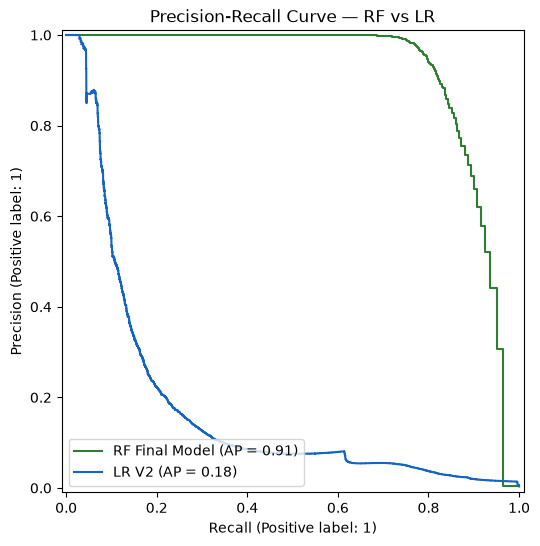

In [21]:
# PR Curve
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba_rf_no_leak_v2, name='RF Final Model', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba_lr_v2, name='LR V2', ax=ax)

# set colors of curves for visual appeal
colors = ['#2E7D32', '#1565C0']
for line, color in zip(ax.lines, colors):
    line.set_color(color)

# ensures legend colors are correct
for line, color in zip(ax.lines, colors):
    line.set_color(color)
ax.legend(loc='lower left')

plt.title('Precision-Recall Curve — RF vs LR')
plt.savefig('../images/pr_curve.png', bbox_inches='tight')
plt.show()

The plot shows LR dropping off almost immediately after very low `recall`, then flattens near-zero for most of the `recall` range. This matches what was found earlier in `3.5.3`, LR compensates for lost signal by casting a wide net, sacrificing `precision`. 

Looking at RF, RF stays flat near `precision = 1.0` for a long stretch of `recall`, only dropping steeply near `recall` ~0.95-1. This shows that RF can achieve high `recall` while barely sacrificing `precision`, until its pushed to the extreme, whereas LR sacrifices `precision` almost immediately. 

The ROC curve plots True Positive Rate (`recall`) against False Positive Rate across all decision thresholds, giving a threshold-independent view of each model's discriminative ability. A curve closer to the upper-left indicates better performance. However, given the severe class imbalance in this dataset, `ROC-AUC` can appear deceptively high even when `precision` is poor (as seen with `LR V2`) — so this curve should be read alongside the PR curve above, not in isolation.

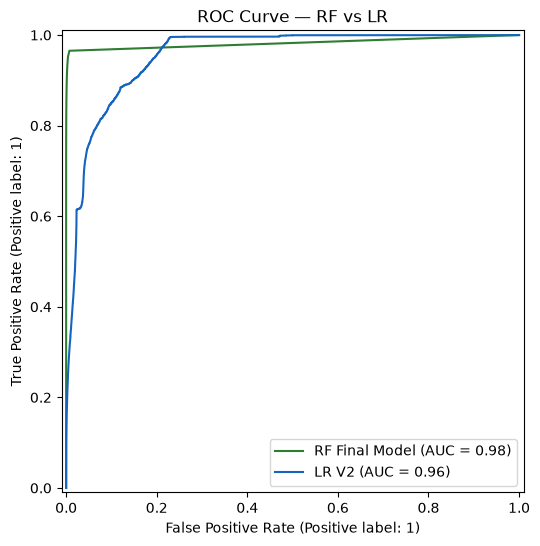

In [20]:
# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf_no_leak_v2, name='RF Final Model', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_pred_proba_lr_v2, name='LR V2', ax=ax)

# set colors of curves for visual appeal
colors = ['#2E7D32', '#1565C0']

# ensures legend colors are correct
for line, color in zip(ax.lines, colors):
    line.set_color(color)
ax.legend(loc='lower right')

plt.title('ROC Curve — RF vs LR')
plt.savefig('../images/roc_curve.png', bbox_inches='tight')
plt.show()

The plot shows LR as deceptively strong (`AUC = 0.96`), barely behind RF (0.98), despite AP being 0.18 vs. 0.91. This further reinforces the fact that `ROC-AUC` is misleading under imbalance. 

## 3.8 Feature Importance

Using the tuned Random Forest's feature_importances_ attribute to rank features by their contribution to reducing Gini impurity across all trees, features above the 0.025 importance threshold will be retained for retraining — this identifies which features drive the model's predictions and informs the behavioral explanation of top predictors.

In [ ]:

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False) # sorts features from most to least important

feature_importance.reset_index(drop=True, inplace=True) # resets the indexes so that they can be numbered like a list
feature_importance.index += 1
feature_importance

## 3.9 Final Model Comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['LR Baseline', 'LR Tuned', 'RF Baseline', 'RF Tuned', 'RF Retrained'],
    'Churn Precision': [0.53, 0.53, 0.56, 0.52, 0.52],
    'Churn Recall': [0.82, 0.82, 0.64, 0.84, 0.86],
    'Churn F1': [0.64, 0.64, 0.60, 0.64, 0.65],
    'Accuracy': [0.76, 0.76, 0.77, 0.75, 0.75],
    'AUC-ROC': [0.861, 0.861, 0.831, 0.862, 0.863]
})
results.style.hide().format('{:g}', subset=['Churn Precision', 'Churn Recall', 'Churn F1', 'Accuracy', 'AUC-ROC'])

In [ ]:
metrics = ['Churn Recall', 'AUC-ROC', 'Churn F1']
models = ['LR Baseline', 'LR Tuned', 'RF Baseline', 'RF Tuned', 'RF Retrained']

# values for each metric across models
churn_recall = [0.82, 0.82, 0.64, 0.84, 0.86]
auc_roc = [0.861, 0.861, 0.831, 0.862, 0.863]
churn_f1 = [0.64, 0.64, 0.60, 0.64, 0.65]

x = np.arange(len(metrics))
width = 0.15  # width of each bar
colors = ['#1565C0', '#90CAF9', '#2E7D32', '#A5D6A7', '#66CEA2'] # for visual appeal
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - 2.0*width, [churn_recall[0], auc_roc[0], churn_f1[0]], width, label='LR Baseline', color=colors[0])
ax.bar(x - 1.0*width, [churn_recall[1], auc_roc[1], churn_f1[1]], width, label='LR Tuned', color=colors[1])
ax.bar(x + 0.0*width, [churn_recall[2], auc_roc[2], churn_f1[2]], width, label='RF Baseline', color=colors[2])
ax.bar(x + 1.0*width, [churn_recall[3], auc_roc[3], churn_f1[3]], width, label='RF Tuned', color=colors[3])
ax.bar(x + 2.0*width, [churn_recall[4], auc_roc[4], churn_f1[4]], width, label='RF Retrained', color=colors[4], edgecolor='red', linewidth=1.0)

ax.set_ylim(0.55, 0.90) # to better visualize the difference

ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_title('Model Comparison — Key Metrics')
plt.savefig('../images/model_comparison.png', bbox_inches='tight')
plt.show()

## 3.10 Segementation Analysis 

## 3.11 Model Recommendation / Limitations